# Two-Tower Embedding Model

Produces event and user embeddings in a shared 64-dim latent space.

- **Event tower**: MLP on frozen SentenceTransformer embeddings of event titles
- **User tower**: Self-attention over frozen SentenceTransformer embeddings of last N attended events, pooled via learned query token
- **Loss**: InfoNCE (contrastive) with in-batch negatives

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Load Raw Data

In [2]:
data_dir = os.path.join('..', 'data', 'raw')

events_df = pd.read_csv(os.path.join(data_dir, 'meta-events.csv'))
rsvps_df = pd.read_csv(os.path.join(data_dir, 'rsvps.csv'))
groups_df = pd.read_csv(os.path.join(data_dir, 'meta-groups.csv'))

print(f'Events: {len(events_df):,}')
print(f'RSVPs:  {len(rsvps_df):,}')
print(f'Groups: {len(groups_df):,}')

events_df = events_df.dropna(subset=['name'])
events_df = events_df.merge(groups_df[['group_id', 'category_name']], on='group_id', how='left')
events_df['category_name'] = events_df['category_name'].fillna('Unknown')

# Build group_id index for learnable group embeddings
all_group_ids = sorted(events_df['group_id'].unique())
group_id_to_idx = {gid: i for i, gid in enumerate(all_group_ids)}
num_groups = len(group_id_to_idx)

# Map event_id -> group index
events_df['event_id'] = events_df['event_id'].astype(str)
event_to_group_idx = events_df.set_index('event_id')['group_id'].map(group_id_to_idx).to_dict()

print(f'Events after cleaning: {len(events_df):,}')
print(f'Unique groups: {num_groups}')
events_df.head()

Events: 19,307
RSVPs:  126,813
Groups: 602
Events after cleaning: 19,307
Unique groups: 602


,event_id,group_id,name,time,category_name
0,243930425,26140018,2017 Nashville Walk to End Alzheimers - Octob...,2017-10-14 12:00:00,Community & Environment
1,244208851,25604533,Steak Dinner on the Patio,2017-10-15 00:15:00,Pets & Animals
2,pxlktnywnbfb,25973656,Schedule Meetup,2017-10-03 23:30:00,Support
3,244444551,18571126,"Happy Hour Wednesday, Jonathan's Green Hills, ...",2017-10-25 22:30:00,Career & Business
4,244257722,18571126,"Happy Hour Wednesday, Brentwood, Oct. 18",2017-10-18 22:30:00,Career & Business


## Build User Histories

In [3]:
MAX_HISTORY = 20

# Keep only 'yes' RSVPs for events we have metadata for
valid_event_ids = set(events_df['event_id'].astype(str))
rsvps_clean = rsvps_df.copy()
rsvps_clean['event_id'] = rsvps_clean['event_id'].astype(str)
rsvps_clean['member_id'] = rsvps_clean['member_id'].astype(str)
rsvps_clean = rsvps_clean[rsvps_clean['event_id'].isin(valid_event_ids)]

events_df['event_id'] = events_df['event_id'].astype(str)

# Sort RSVPs by event time so history is chronological
event_time = events_df.set_index('event_id')['time'].to_dict()
rsvps_clean['event_time'] = rsvps_clean['event_id'].map(event_time)
rsvps_clean = rsvps_clean.dropna(subset=['event_time'])
rsvps_clean = rsvps_clean.sort_values('event_time')

# Build per-user chronological event history
user_histories = defaultdict(list)
for _, row in rsvps_clean.iterrows():
    user_histories[row['member_id']].append(row['event_id'])

# Filter to users with at least 2 events (need history + target)
user_histories = {uid: evts for uid, evts in user_histories.items() if len(evts) >= 2}

print(f'Users with >= 2 events: {len(user_histories):,}')
hist_lens = [len(v) for v in user_histories.values()]
print(f'History length — median: {np.median(hist_lens):.0f}, mean: {np.mean(hist_lens):.1f}, max: {max(hist_lens)}')

Users with >= 2 events: 13,797
History length — median: 4, mean: 8.4, max: 513


## Pre-compute Sentence Embeddings for All Event Titles

In [4]:
st_model = SentenceTransformer('all-MiniLM-L6-v2')

event_titles = events_df.set_index('event_id')['name'].to_dict()
event_ids_ordered = list(event_titles.keys())
titles_list = [event_titles[eid] for eid in event_ids_ordered]

print(f'Encoding {len(titles_list):,} event titles...')
title_embeddings = st_model.encode(titles_list, show_progress_bar=True, batch_size=256)
title_embeddings = torch.tensor(title_embeddings, dtype=torch.float32)
print(f'Embedding shape: {title_embeddings.shape}')  # [num_events, 384]

# Map event_id -> embedding tensor
event_id_to_idx = {eid: i for i, eid in enumerate(event_ids_ordered)}
print('Done.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 19,307 event titles...


Batches:   0%|          | 0/76 [00:00<?, ?it/s]

Embedding shape: torch.Size([19307, 384])
Done.


## Build Training Dataset

For each user, we take each attended event as a positive. The user's history is all events they attended before that event (up to last N). In-batch negatives provide the contrastive signal.

In [5]:
class TwoTowerDataset(Dataset):
    """
    Each sample: (history_embs, history_group_idxs, history_len, target_emb, target_group_idx)
    Applies random history dropout during training for regularization.
    """
    def __init__(self, user_histories, event_id_to_idx, event_to_group_idx,
                 title_embeddings, max_history=MAX_HISTORY, history_dropout=0.0):
        self.samples = []  # (history_event_indices, history_group_indices, target_event_idx, target_group_idx)
        self.title_embeddings = title_embeddings
        self.max_history = max_history
        self.history_dropout = history_dropout
        
        for uid, events in user_histories.items():
            for t in range(1, len(events)):
                target_eid = events[t]
                if target_eid not in event_id_to_idx:
                    continue
                target_gidx = event_to_group_idx.get(target_eid, 0)
                
                history_eids = events[max(0, t - max_history):t]
                history_idxs = []
                history_gidxs = []
                for e in history_eids:
                    if e in event_id_to_idx:
                        history_idxs.append(event_id_to_idx[e])
                        history_gidxs.append(event_to_group_idx.get(e, 0))
                if len(history_idxs) == 0:
                    continue
                self.samples.append((history_idxs, history_gidxs, 
                                     event_id_to_idx[target_eid], target_gidx))
        
        print(f'Built {len(self.samples):,} samples (history_dropout={history_dropout})')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        history_idxs, history_gidxs, target_idx, target_gidx = self.samples[idx]
        
        # Random history dropout: randomly drop events from history during training
        if self.history_dropout > 0 and len(history_idxs) > 1:
            keep_mask = np.random.random(len(history_idxs)) > self.history_dropout
            if keep_mask.sum() == 0:  # keep at least one
                keep_mask[np.random.randint(len(history_idxs))] = True
            history_idxs = [h for h, k in zip(history_idxs, keep_mask) if k]
            history_gidxs = [g for g, k in zip(history_gidxs, keep_mask) if k]
        
        history_embs = self.title_embeddings[history_idxs]  # [H, 384]
        history_gidxs_t = torch.tensor(history_gidxs, dtype=torch.long)
        target_emb = self.title_embeddings[target_idx]
        target_gidx_t = torch.tensor(target_gidx, dtype=torch.long)
        return history_embs, history_gidxs_t, len(history_idxs), target_emb, target_gidx_t


def collate_fn(batch):
    """Pad variable-length histories to the max length in the batch."""
    histories, hist_groups, lengths, targets, target_groups = zip(*batch)
    max_len = max(lengths)
    emb_dim = histories[0].shape[-1]
    
    padded = torch.zeros(len(batch), max_len, emb_dim)
    padded_groups = torch.zeros(len(batch), max_len, dtype=torch.long)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    
    for i, (h, g, l) in enumerate(zip(histories, hist_groups, lengths)):
        padded[i, :l] = h
        padded_groups[i, :l] = g
        mask[i, :l] = True
    
    targets = torch.stack(targets)
    target_groups = torch.stack(target_groups)
    return padded, padded_groups, mask, targets, target_groups

In [6]:
# Chronological split: last 20% of each user's events for validation
train_histories = {}

for uid, events in user_histories.items():
    split_idx = max(2, int(len(events) * 0.8))
    train_histories[uid] = events[:split_idx]

val_histories_split = {}
for uid, events in user_histories.items():
    split_idx = max(2, int(len(events) * 0.8))
    if split_idx < len(events):
        val_histories_split[uid] = events


class TwoTowerValDataset(TwoTowerDataset):
    """Only creates samples where the target is in the val portion."""
    def __init__(self, user_histories, event_id_to_idx, event_to_group_idx,
                 title_embeddings, train_split_ratio=0.8, max_history=MAX_HISTORY):
        self.samples = []
        self.title_embeddings = title_embeddings
        self.max_history = max_history
        self.history_dropout = 0.0  # no dropout at val time
        
        for uid, events in user_histories.items():
            split_idx = max(2, int(len(events) * train_split_ratio))
            for t in range(split_idx, len(events)):
                target_eid = events[t]
                if target_eid not in event_id_to_idx:
                    continue
                target_gidx = event_to_group_idx.get(target_eid, 0)
                history_eids = events[max(0, t - max_history):t]
                history_idxs = []
                history_gidxs = []
                for e in history_eids:
                    if e in event_id_to_idx:
                        history_idxs.append(event_id_to_idx[e])
                        history_gidxs.append(event_to_group_idx.get(e, 0))
                if len(history_idxs) == 0:
                    continue
                self.samples.append((history_idxs, history_gidxs,
                                     event_id_to_idx[target_eid], target_gidx))
        
        print(f'Built {len(self.samples):,} validation samples')


BATCH_SIZE = 512

train_dataset = TwoTowerDataset(
    train_histories, event_id_to_idx, event_to_group_idx,
    title_embeddings, history_dropout=0.2  # drop 20% of history events randomly
)
val_dataset = TwoTowerValDataset(
    val_histories_split, event_id_to_idx, event_to_group_idx, title_embeddings
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          collate_fn=collate_fn, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        collate_fn=collate_fn, drop_last=False)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Built 77,139 samples (history_dropout=0.2)
Built 25,043 validation samples
Train batches: 150, Val batches: 49


## Two-Tower Model

In [7]:
class EventTower(nn.Module):
    """Projects frozen sentence embeddings + learned group embedding into shared latent space."""
    def __init__(self, input_dim=384, num_groups=1, group_emb_dim=32,
                 hidden_dim=128, output_dim=64, dropout=0.2):
        super().__init__()
        self.group_embedding = nn.Embedding(num_groups, group_emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(input_dim + group_emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )
    
    def forward(self, text_emb, group_idx):
        """
        Args:
            text_emb: [B, 384] frozen sentence embeddings
            group_idx: [B] integer group indices
        """
        g = self.group_embedding(group_idx)  # [B, group_emb_dim]
        x = torch.cat([text_emb, g], dim=-1)  # [B, 384 + group_emb_dim]
        return self.mlp(x)  # [B, 64]


class UserTower(nn.Module):
    """Attention-pooled aggregation of user's event history (titles + groups)."""
    def __init__(self, input_dim=384, num_groups=1, group_emb_dim=32,
                 hidden_dim=128, output_dim=64, n_heads=4, n_layers=2, dropout=0.2):
        super().__init__()
        self.group_embedding = nn.Embedding(num_groups, group_emb_dim)
        self.input_proj = nn.Linear(input_dim + group_emb_dim, hidden_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=n_heads, dim_feedforward=hidden_dim * 2,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        self.cls_token = nn.Parameter(torch.randn(1, 1, hidden_dim))
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, output_dim),
            nn.Dropout(dropout),
        )
    
    def forward(self, history_embs, history_groups, history_mask):
        """
        Args:
            history_embs: [B, N, 384]
            history_groups: [B, N] integer group indices
            history_mask: [B, N] True where valid
        """
        B = history_embs.shape[0]
        
        g = self.group_embedding(history_groups)  # [B, N, group_emb_dim]
        x = torch.cat([history_embs, g], dim=-1)  # [B, N, 384 + group_emb_dim]
        x = self.input_proj(x)  # [B, N, hidden]
        
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        
        cls_mask = torch.ones(B, 1, dtype=torch.bool, device=x.device)
        full_mask = torch.cat([cls_mask, history_mask], dim=1)
        padding_mask = ~full_mask
        
        x = self.transformer(x, src_key_padding_mask=padding_mask)
        cls_out = x[:, 0, :]
        return self.output_proj(cls_out)


class TwoTowerModel(nn.Module):
    def __init__(self, input_dim=384, num_groups=1, group_emb_dim=32,
                 hidden_dim=128, output_dim=64, n_heads=4, n_layers=2, 
                 dropout=0.2, temperature=0.07):
        super().__init__()
        self.event_tower = EventTower(input_dim, num_groups, group_emb_dim,
                                       hidden_dim, output_dim, dropout)
        self.user_tower = UserTower(input_dim, num_groups, group_emb_dim,
                                     hidden_dim, output_dim, n_heads, n_layers, dropout)
        self.temperature = temperature
    
    def forward(self, history_embs, history_groups, history_mask, 
                target_embs, target_groups):
        user_embs = self.user_tower(history_embs, history_groups, history_mask)
        event_embs = self.event_tower(target_embs, target_groups)
        
        user_embs = F.normalize(user_embs, dim=-1)
        event_embs = F.normalize(event_embs, dim=-1)
        return user_embs, event_embs
    
    def info_nce_loss(self, user_embs, event_embs):
        """Symmetric InfoNCE with in-batch negatives."""
        logits = user_embs @ event_embs.T / self.temperature
        labels = torch.arange(logits.shape[0], device=logits.device)
        loss_u2e = F.cross_entropy(logits, labels)
        loss_e2u = F.cross_entropy(logits.T, labels)
        return (loss_u2e + loss_e2u) / 2


model = TwoTowerModel(num_groups=num_groups, group_emb_dim=32, dropout=0.2).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
print(model)

Trainable parameters: 426,880
TwoTowerModel(
  (event_tower): EventTower(
    (group_embedding): Embedding(602, 32)
    (mlp): Sequential(
      (0): Linear(in_features=416, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (user_tower): UserTower(
    (group_embedding): Embedding(602, 32)
    (input_proj): Linear(in_features=416, out_features=128, bias=True)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=256, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (linear2): Linear(in_features=256, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwis

## Training Loop

In [8]:
EPOCHS = 30
LR = 3e-4
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    epoch_loss = 0.0
    for history, hist_groups, mask, targets, target_groups in train_loader:
        history = history.to(device)
        hist_groups = hist_groups.to(device)
        mask = mask.to(device)
        targets = targets.to(device)
        target_groups = target_groups.to(device)
        
        user_embs, event_embs = model(history, hist_groups, mask, targets, target_groups)
        loss = model.info_nce_loss(user_embs, event_embs)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    scheduler.step()
    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)
    
    # --- Validate ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for history, hist_groups, mask, targets, target_groups in val_loader:
            history = history.to(device)
            hist_groups = hist_groups.to(device)
            mask = mask.to(device)
            targets = targets.to(device)
            target_groups = target_groups.to(device)
            
            user_embs, event_embs = model(history, hist_groups, mask, targets, target_groups)
            loss = model.info_nce_loss(user_embs, event_embs)
            val_loss += loss.item()
    
    avg_val = val_loss / max(len(val_loader), 1)
    val_losses.append(avg_val)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}')

/home/blalo/miniconda3/envs/dl/lib/python3.12/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647406761/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch   1/30 | Train Loss: 5.1634 | Val Loss: 4.5211 | LR: 2.99e-04
Epoch   5/30 | Train Loss: 3.5930 | Val Loss: 4.0143 | LR: 2.80e-04
Epoch  10/30 | Train Loss: 3.3594 | Val Loss: 3.9188 | LR: 2.25e-04
Epoch  15/30 | Train Loss: 3.2501 | Val Loss: 3.8788 | LR: 1.50e-04
Epoch  20/30 | Train Loss: 3.1941 | Val Loss: 3.8658 | LR: 7.50e-05
Epoch  25/30 | Train Loss: 3.1555 | Val Loss: 3.8577 | LR: 2.01e-05
Epoch  30/30 | Train Loss: 3.1496 | Val Loss: 3.8602 | LR: 0.00e+00


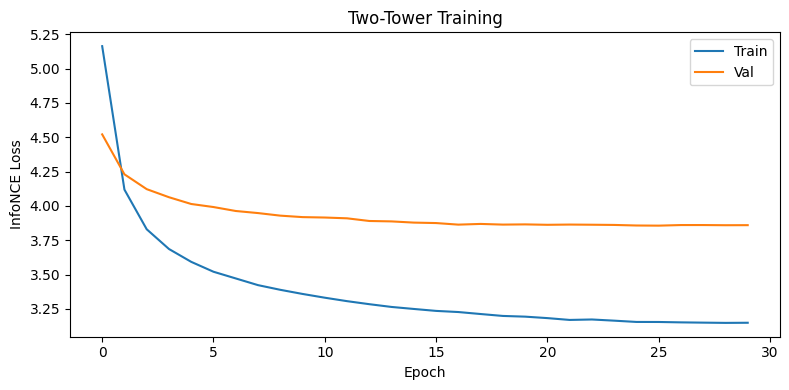

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('InfoNCE Loss')
ax.set_title('Two-Tower Training')
ax.legend()
plt.tight_layout()
plt.show()

## Evaluate: Recall@K

In [10]:
@torch.no_grad()
def compute_recall_at_k(model, dataloader, title_embeddings, event_ids_ordered,
                        event_to_group_idx, ks=[1, 5, 10, 50]):
    """For each (user, target_event) pair, rank all events and check if target is in top-K."""
    model.eval()
    
    # Pre-compute all event embeddings through the event tower
    all_text = title_embeddings.to(device)
    all_groups = torch.tensor(
        [event_to_group_idx.get(eid, 0) for eid in event_ids_ordered],
        dtype=torch.long, device=device
    )
    event_tower_embs = F.normalize(model.event_tower(all_text, all_groups), dim=-1)  # [E, 64]
    
    hits = {k: 0 for k in ks}
    total = 0
    
    for history, hist_groups, mask, targets, target_groups in dataloader:
        history = history.to(device)
        hist_groups = hist_groups.to(device)
        mask = mask.to(device)
        targets = targets.to(device)
        target_groups = target_groups.to(device)
        
        user_embs, _ = model(history, hist_groups, mask, targets, target_groups)
        
        # Score against ALL events
        scores = user_embs @ event_tower_embs.T  # [B, E]
        
        # Target event scores
        target_event_embs = F.normalize(model.event_tower(targets, target_groups), dim=-1)
        target_scores = (user_embs * target_event_embs).sum(dim=-1)  # [B]
        
        ranks = (scores > target_scores.unsqueeze(1)).sum(dim=1) + 1
        
        for k in ks:
            hits[k] += (ranks <= k).sum().item()
        total += len(ranks)
    
    recall = {k: hits[k] / total for k in ks}
    return recall


recall = compute_recall_at_k(model, val_loader, title_embeddings, 
                             event_ids_ordered, event_to_group_idx)
print('Validation Recall@K:')
for k, v in recall.items():
    print(f'  R@{k:3d}: {v:.4f}')

Validation Recall@K:
  R@  1: 0.0663
  R@  5: 0.1282
  R@ 10: 0.1828
  R@ 50: 0.4643


## Export Embeddings

Generate final event and user embeddings for the downstream seeding model.

In [11]:
model.eval()
output_dir = os.path.join('..', 'data')

# --- Event embeddings ---
with torch.no_grad():
    all_text = title_embeddings.to(device)
    all_groups = torch.tensor(
        [event_to_group_idx.get(eid, 0) for eid in event_ids_ordered],
        dtype=torch.long, device=device
    )
    all_event_embs = F.normalize(
        model.event_tower(all_text, all_groups), dim=-1
    ).cpu().numpy()  # [E, 64]

event_emb_df = pd.DataFrame(
    all_event_embs, 
    columns=[f'dim_{i}' for i in range(all_event_embs.shape[1])]
)
event_emb_df.insert(0, 'event_id', [f'e_{eid}' for eid in event_ids_ordered])
event_emb_df.to_csv(os.path.join(output_dir, 'event_embeddings.csv'), index=False)
print(f'Saved event embeddings: {event_emb_df.shape}')

# --- User embeddings ---
user_ids = []
user_emb_list = []

with torch.no_grad():
    for uid, events in user_histories.items():
        history_idxs = []
        history_gidxs = []
        for e in events:
            if e in event_id_to_idx:
                history_idxs.append(event_id_to_idx[e])
                history_gidxs.append(event_to_group_idx.get(e, 0))
        if len(history_idxs) == 0:
            continue
        # Truncate to max history
        history_idxs = history_idxs[-MAX_HISTORY:]
        history_gidxs = history_gidxs[-MAX_HISTORY:]
        
        history_embs = title_embeddings[history_idxs].unsqueeze(0).to(device)
        hist_groups = torch.tensor(history_gidxs, dtype=torch.long).unsqueeze(0).to(device)
        mask = torch.ones(1, len(history_idxs), dtype=torch.bool, device=device)
        
        user_emb = model.user_tower(history_embs, hist_groups, mask)
        user_emb = F.normalize(user_emb, dim=-1)
        user_emb_list.append(user_emb.cpu())
        user_ids.append(f'm_{uid}')

user_emb_tensor = torch.cat(user_emb_list, dim=0).numpy()
user_emb_df = pd.DataFrame(
    user_emb_tensor,
    columns=[f'dim_{i}' for i in range(user_emb_tensor.shape[1])]
)
user_emb_df.insert(0, 'member_id', user_ids)
user_emb_df.to_csv(os.path.join(output_dir, 'user_embeddings.csv'), index=False)
print(f'Saved user embeddings: {user_emb_df.shape}')

Saved event embeddings: (19307, 65)
Saved user embeddings: (13797, 65)


## Susceptibility Function for Contagion Simulation

The two-tower cosine similarity gives us a **relative affinity** score in [-1, 1].
We map this to a per-(user, event) susceptibility that plugs into the simulator's infection formula:

$$p_{\text{inf}} = 1 - (1 - \beta)^m \cdot (1 - \beta_\Delta)^n$$

We scale the base transmission rates by the user's affinity for the event:

$$\beta(u, e) = \beta_{\text{base}} \cdot (1 + \text{affinity}), \quad \beta_\Delta(u, e) = \beta_{\Delta,\text{base}} \cdot (1 + \text{affinity})$$

where $\text{affinity} = \frac{\cos(\mathbf{z}_u, \mathbf{z}_e) + 1}{2} \in [0, 1]$. This means:
- A user with **zero** affinity gets the base rates (e.g. 0.03, 0.10)
- A user with **max** affinity gets 2x the base rates (e.g. 0.06, 0.20)

## Visualize Embedding Space (t-SNE)

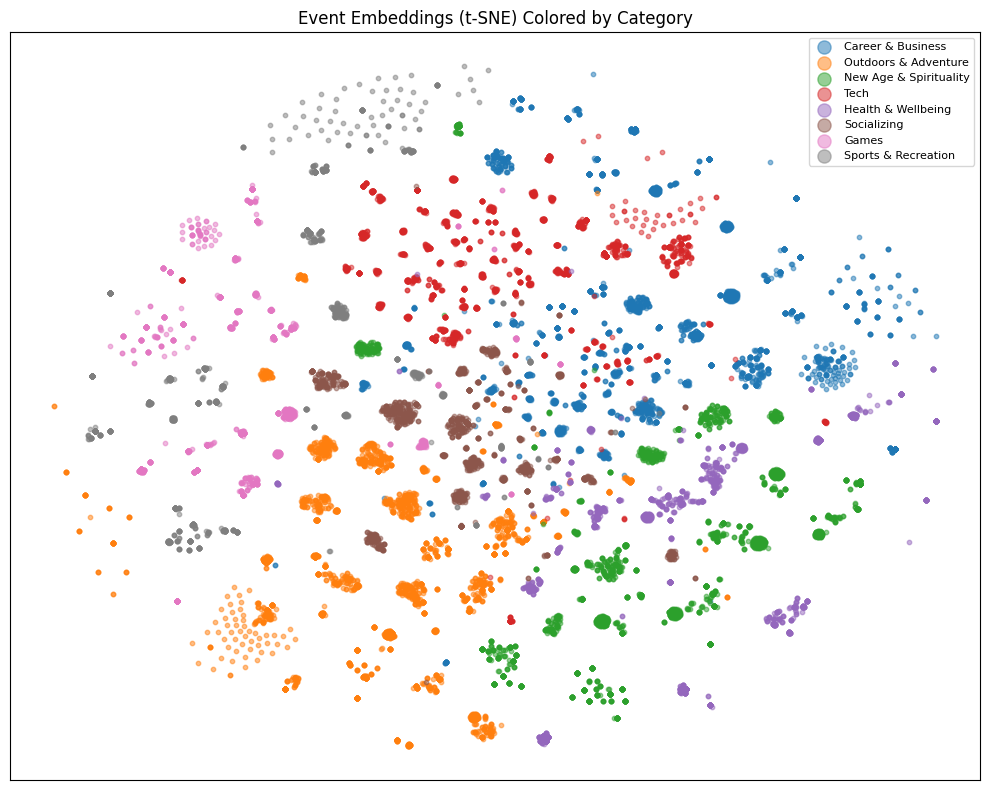

In [13]:
from sklearn.manifold import TSNE
from collections import Counter
import matplotlib.pyplot as plt

# t-SNE on event embeddings, colored by category
event_categories = events_df.set_index('event_id')['category_name'].to_dict()
cats = [event_categories.get(eid, 'Unknown') for eid in event_ids_ordered]

# Take top 8 categories for legibility
top_cats = [c for c, _ in Counter(cats).most_common(8)]
cat_mask = np.array([c in top_cats for c in cats])

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embs_2d = tsne.fit_transform(all_event_embs[cat_mask])
cats_filtered = np.array(cats)[cat_mask]

fig, ax = plt.subplots(figsize=(10, 8))
for cat in top_cats:
    mask = cats_filtered == cat
    ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1], label=cat, alpha=0.5, s=10)
ax.legend(fontsize=8, markerscale=3)
ax.set_title('Event Embeddings (t-SNE) Colored by Category')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()